# Clasificación Automática de Modulaciones (AMC)
## Entrenamiento — TCN de dos ramas (I/Q + Amplitud/Fase)

Este notebook entrena `DualTCN` (`../common/models.py`): una rama TCN sobre **I/Q** y otra sobre
**Amplitud/Fase** de la misma señal, con una cabeza de clasificación común sobre los dos embeddings
concatenados. La idea (feedback del tutor, punto 5) es que tener una representación no quita la otra:
A/φ le simplifica a la red parte del trabajo, e I/Q conserva la información sin transformar.

El modelo recibe **I/Q crudo** y calcula A/φ adentro del `forward`, así que los loaders, la augmentation
(`augment_rotate_iq`, que actúa sobre I/Q) y el curriculum son los mismos que en `../tcn/` y `../tcn_ap/`,
y al desplegar solo hace falta I/Q. Cada rama tiene su propio `BatchNorm1d` de entrada porque las escalas
(I/Q y amplitud ≈ 0.005, fase en radianes) son muy distintas.

`MODEL_KWARGS["channels"]` es el ancho de **cada** rama: los parámetros son ~2x los de una `TCN` del mismo
ancho. Se dejó `channels=40` para quedar cerca de los parámetros de `tcn/` (75k) y `tcn_ap/` (100k) y que la
comparación no mezcle "dos ramas" con "más capacidad". La config queda guardada en `history.pkl`
(`model_kwargs`), así `comparacion.ipynb` puede reconstruir el modelo exacto.

## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import DualTCN
from common.data import load_radioml_digital, split_dataset, make_loader, augment_rotate_iq
from common.train import train_model, SNRCurriculum, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — `channels` es el ancho de CADA rama (I/Q y A/φ).
# No incluye n_classes (se completa con el dataset).
MODEL_KWARGS = dict(channels=40, dilations=(1, 2, 4, 8), dropout=0.2)

# Entrenamiento por grupos de SNR (ver common/train.py::SNRCurriculum). Poner USE_CURRICULUM = False
# para entrenar con todos los SNR mezclados desde el inicio. En modo curriculum `PATIENCE` no se usa
# y EPOCHS es solo un tope global de seguridad.
USE_CURRICULUM = True
CURRICULUM_KWARGS = dict(group_size=4, patience=3, min_gain=0.005, max_epochs_per_stage=15)
if USE_CURRICULUM:
    EPOCHS = 80

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga y preparación del dataset (I/Q; A/φ se calcula dentro del modelo)

In [2]:
X, y, snrs, le = load_radioml_digital(seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)

# Augmentation por rotación de constelación I/Q, solo en train (mismo criterio que tcn/ y tcn_ap/).
# A/φ se deriva adentro del modelo DESPUÉS de rotar, así que no hay que transformar nada acá.
X_train, y_train, snr_train = augment_rotate_iq(X_train, y_train, snr_train)
print(f"Train (aumentado): {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
Train (aumentado): (384000, 2, 128) | Val: (32000, 2, 128) | Test: (32000, 2, 128)


## 3. Entrenamiento — TCN de dos ramas (I/Q + A/φ)

In [3]:
print("=== DualTCN (I/Q + A/φ) ===")
print(f"Configuración: {MODEL_KWARGS}")
model = DualTCN(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

curriculum = (SNRCurriculum(X_train, y_train, snr_train, batch_size=BATCH_SIZE, **CURRICULUM_KWARGS)
              if USE_CURRICULUM else None)

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE, curriculum=curriculum
)
history["model_kwargs"] = MODEL_KWARGS
history["curriculum"] = CURRICULUM_KWARGS if USE_CURRICULUM else None

torch.save(model.state_dict(), "tcn_iq_ap.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== DualTCN (I/Q + A/φ) ===
Configuración: {'channels': 40, 'dilations': (1, 2, 4, 8), 'dropout': 0.2}
Parámetros: 79,616
[curriculum] etapa 1/5: SNR >= 12 dB (76640 muestras)
Época   1 | SNR >=  12 dB | Train Loss: 0.5703 | Val Loss: 2.2966 | Val Acc: 0.4502 (mejor 0.4502)
Época   2 | SNR >=  12 dB | Train Loss: 0.2340 | Val Loss: 2.3005 | Val Acc: 0.4695 (mejor 0.4695)
Época   3 | SNR >=  12 dB | Train Loss: 0.1850 | Val Loss: 2.2520 | Val Acc: 0.4725 (mejor 0.4695)
Época   4 | SNR >=  12 dB | Train Loss: 0.1648 | Val Loss: 2.1993 | Val Acc: 0.4837 (mejor 0.4837)
Época   5 | SNR >=  12 dB | Train Loss: 0.1501 | Val Loss: 2.1362 | Val Acc: 0.4815 (mejor 0.4837)
Época   6 | SNR >=  12 dB | Train Loss: 0.1395 | Val Loss: 2.2100 | Val Acc: 0.4878 (mejor 0.4837)
Época   7 | SNR >=  12 dB | Train Loss: 0.1319 | Val Loss: 2.1054 | Val Acc: 0.4866 (mejor 0.4837)
[curriculum] etapa 2/5: SNR >= 4 dB (153820 muestras)
Época   8 | SNR >=   4 dB | Train Loss: 0.1631 | Val Loss: 1.7411 | Val Acc: 

## 4. Evaluación

In [4]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — DualTCN (I/Q + A/φ): {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

Accuracy global — DualTCN (I/Q + A/φ): 0.6493
Parámetros: 79,616


## 5. Gráficos

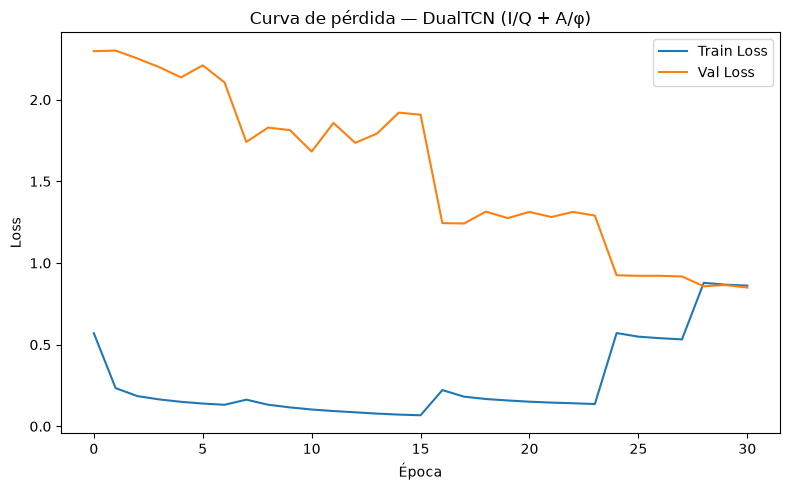

In [5]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — DualTCN (I/Q + A/φ)")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

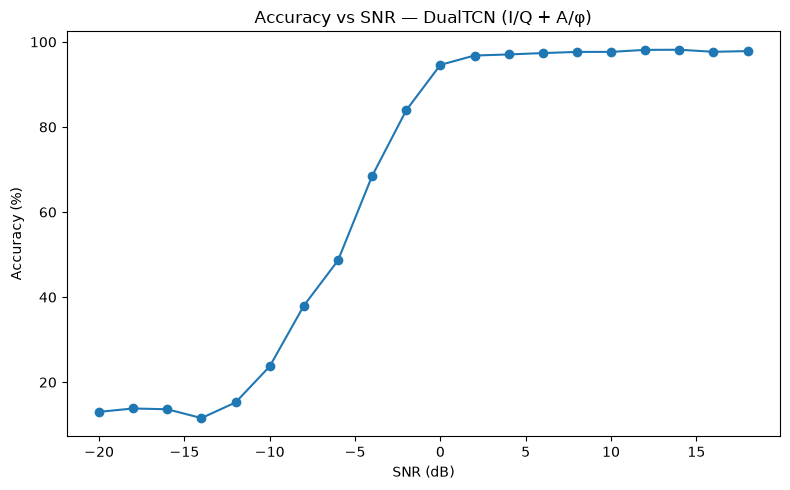

In [6]:
# Accuracy vs SNR
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — DualTCN (I/Q + A/φ)")
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

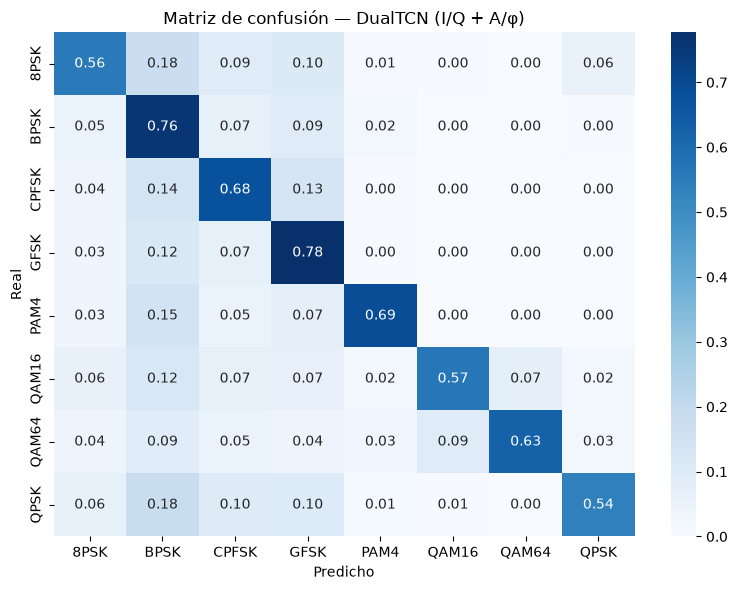

In [7]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — DualTCN (I/Q + A/φ)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

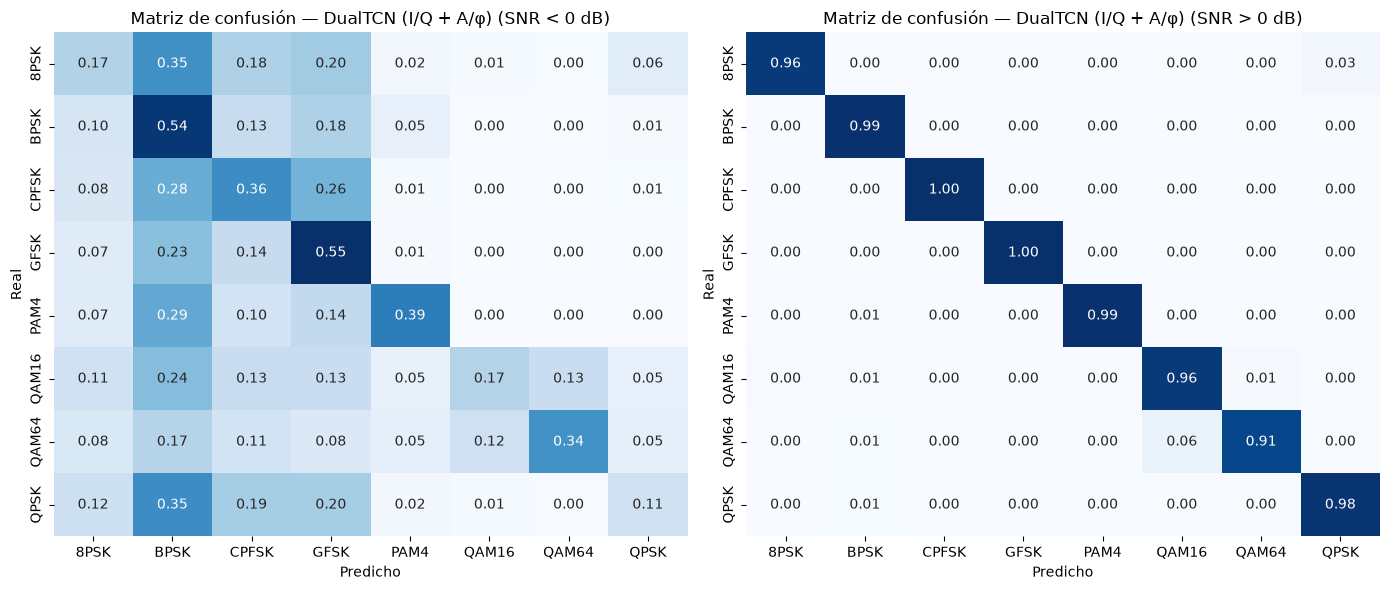

In [8]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — DualTCN (I/Q + A/φ) ({titulo})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()

In [9]:
# --- Guardar esta corrida (no pisa nada: cada ejecución crea su propia carpeta) ---------------------
# Pegar como celda NUEVA DESPUÉS de la celda de evaluación de cada notebook. Usa las variables que el
# notebook ya tiene (model, history, acc, snr_acc, X_test, y_test, snr_test, MODEL_KWARGS, BATCH_SIZE,
# EPOCHS, PATIENCE, SEED). Guarda en Resultados/sweep/<id>/ con el mismo formato que Resultados/sweep.py,
# así `python Resultados/sweep.py --resumen` junta corridas de notebooks y del barrido en una tabla.
import json
from datetime import datetime
from pathlib import Path

LR = 1e-3        # <-- poner el lr que se usó en train_model(...) de ESTE notebook (lstm: 3e-4)
AUGMENT = True   # <-- False si se entrenó sin augment_rotate_iq

_folder = globals().get("RUN_NAME", Path.cwd().name)  # cnn, lstm, gru, tcn, cnn_ap, tcn_ap, cnn_preproc
_ARCH = {"cnn": ("cnn", "iq"), "lstm": ("lstm", "iq"), "gru": ("gru", "iq"), "tcn": ("tcn", "iq"),
         "cnn_ap": ("cnn", "ap"), "tcn_ap": ("tcn", "ap"), "cnn_preproc": ("ulcnn", "iq")}
_arch, _repr = _ARCH.get(_folder, (_folder, "iq"))
_cur = bool(globals().get("USE_CURRICULUM", False))
_low, _pos = snr_test <= -10, snr_test > 0

_cfg = {
    "arch": _arch, "repr": _repr, "target": "notebook", "params": int(model.count_parameters()),
    "model_kwargs": {k: (list(v) if isinstance(v, tuple) else v) for k, v in MODEL_KWARGS.items()},
    "lr": LR, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "patience": PATIENCE,
    "augment": AUGMENT, "curriculum": _cur,
    "curriculum_kwargs": globals().get("CURRICULUM_KWARGS") if _cur else None,
    "seed": SEED, "fuente": f"notebook {_folder}", "fecha": datetime.now().isoformat(timespec="seconds"),
}
_metrics = {
    "accuracy_global": float(acc),
    "accuracy_snr_menor_igual_-10": float(overall_accuracy(model, X_test[_low], y_test[_low], device=DEVICE)),
    "accuracy_snr_mayor_0": float(overall_accuracy(model, X_test[_pos], y_test[_pos], device=DEVICE)),
    "accuracy_por_snr": {str(int(k)): float(v) for k, v in snr_acc.items()},
    "parametros": _cfg["params"],
    "epocas_entrenadas": len(history["train_loss"]),
    "mejor_val_acc": float(max(history["val_acc"])),
    "mejor_val_loss": float(min(history["val_loss"])),
    "segundos_entrenamiento": 0.0,  # el notebook no mide el tiempo
}

_rid = (f"{_arch}_{_repr}_p{_cfg['params']}_lr{LR:g}_bs{BATCH_SIZE}_aug{int(AUGMENT)}_cur{int(_cur)}"
        f"_seed{SEED}_nb{datetime.now():%Y%m%d-%H%M%S}")
_out = Path(globals().get("SWEEP_DIR", Path.cwd().resolve().parents[1] / "Resultados" / "sweep")) / _rid
_out.mkdir(parents=True, exist_ok=False)  # falla en vez de pisar si ya existiera
(_out / "config.json").write_text(json.dumps(_cfg, indent=2, ensure_ascii=False), encoding="utf-8")
(_out / "history.json").write_text(json.dumps(
    {k: [float(x) for x in v] for k, v in history.items() if isinstance(v, list)}), encoding="utf-8")
torch.save(model.state_dict(), _out / "model.pt")
(_out / "metrics.json").write_text(json.dumps(_metrics, indent=2), encoding="utf-8")  # marca de "terminada"
print(f"Corrida guardada en {_out}")

Corrida guardada en D:\CEIA\Proyecto_AMC\Resultados\sweep\tcn_iq_ap_iq_p79616_lr0.001_bs256_aug1_cur1_seed42_nb20260923-174436
